# Round 3 Data Analysis
This notebook analyzes the Round 3 market data to understand the main products, their spread behavior, and the relationship between `VELVETFRUIT_EXTRACT` and the `VEV_*` vouchers.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

In [2]:
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

ROUND = 3
DAYS = [0, 1, 2]

price_dfs = []

for day in DAYS:
    price_file_path = DATA_DIR / f"prices_round_{ROUND}_day_{day}.csv"

    price_df = pd.read_csv(price_file_path, sep=";")
    price_df["day"] = day

    price_dfs.append(price_df)

prices_r3 = pd.concat(price_dfs, ignore_index=True)

# 1) D1 products

In [3]:
delta_one_products = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT"]

delta_prices = prices_r3[prices_r3["product"].isin(delta_one_products)].copy()

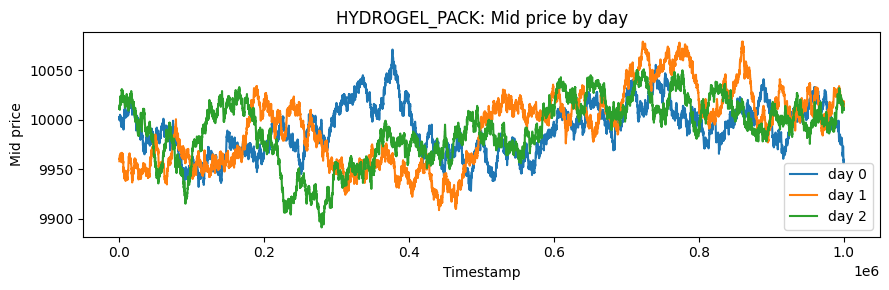

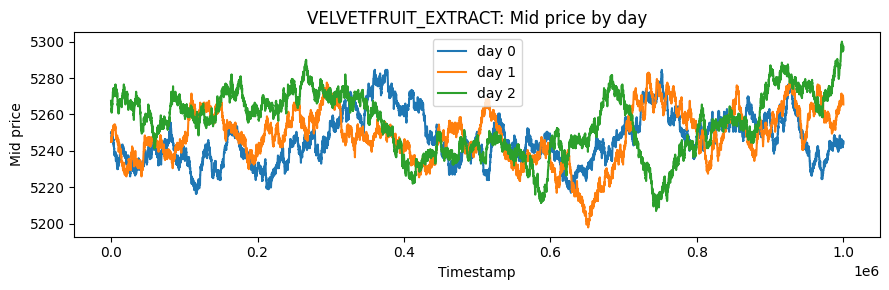

In [4]:
for product in delta_one_products:
    product_df = delta_prices[delta_prices["product"] == product]

    plt.figure(figsize=(9,3))

    for day, day_df in product_df.groupby("day"):
        plt.plot(day_df["timestamp"], day_df["mid_price"], label=f"day {day}")
    
    plt.title(f"{product}: Mid price by day")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid price")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [5]:
delta_prices["spread"] = delta_prices["ask_price_1"] - delta_prices["bid_price_1"]

delta_spread_summary = (delta_prices.groupby(["day", "product"]).agg(mean_spread = ("spread", "mean"),
                                                             median_spread = ("spread", "median"),
                                                             min_spread = ("spread", "min"),
                                                             max_spread = ("spread", "max")
                                                             ))
delta_spread_summary

mean_spread  median_spread  min_spread  max_spread
day product                                                                
0   HYDROGEL_PACK            15.7010           16.0           7          17
    VELVETFRUIT_EXTRACT       4.9935            5.0           1           6
1   HYDROGEL_PACK            15.7264           16.0           7          17
    VELVETFRUIT_EXTRACT       4.9846            5.0           1           6
2   HYDROGEL_PACK            15.7350           16.0           7          17
    VELVETFRUIT_EXTRACT       4.9863            5.0           1           6

In [6]:
delta_spread_data = pd.DataFrame(delta_prices.groupby("product")["spread"].value_counts().sort_index())
delta_spread_data

count
product             spread       
HYDROGEL_PACK       7         275
                    8         490
                    9         225
                    15        798
                    16      27820
                    17        392
VELVETFRUIT_EXTRACT 1         178
                    2        1014
                    3        1003
                    4          71
                    5       22259
                    6        5475

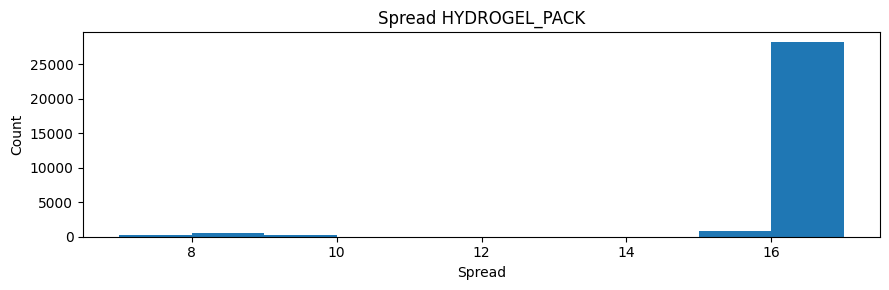

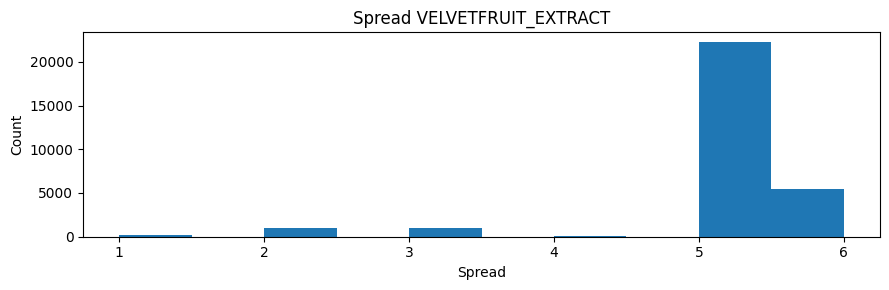

In [7]:
for product in delta_one_products:
    product_df = delta_prices[delta_prices["product"] == product]
    plt.figure(figsize=(9,3))
    plt.hist(product_df["spread"])
    plt.xlabel("Spread")
    plt.ylabel("Count")
    plt.title(f"Spread {product}")
    plt.tight_layout()
    plt.show()
    


`HYDROGEL_PACK` and `VELVETFRUIT_EXTRACT` have very different spread regimes. `HYDROGEL_PACK` usually trades with a spread around `16`, while `VELVETFRUIT_EXTRACT` usually trades with a spread around `5`.

This makes `HYDROGEL_PACK` more suitable for simple passive market making. For `VELVETFRUIT_EXTRACT`, the tighter spread leaves less room for error, so the fair-value estimate is more important.


## 2) Voucher Products

In [8]:
vouchers = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500"
]

voucher_prices = prices_r3[prices_r3["product"].isin(vouchers)].copy()

voucher_prices["spread"] = voucher_prices["ask_price_1"] - voucher_prices["bid_price_1"]


In [9]:
voucher_prices.groupby("product")["mid_price"].agg(["mean","min","max","std"])

,mean,min,max,std
product,,,,
VEV_4000,1250.109800,1198.0,1300.0,15.647243
VEV_4500,750.109567,698.5,799.5,15.639930
VEV_5000,255.022400,206.5,300.5,14.375586
VEV_5100,166.805450,125.0,205.5,12.742624
VEV_5200,95.548767,64.0,122.5,9.664218
VEV_5300,46.759933,26.5,65.5,6.228141
VEV_5400,15.951917,6.5,27.0,3.429182
VEV_5500,6.641350,2.5,12.5,1.738849
VEV_6000,0.500000,0.5,0.5,0.000000


In [10]:
voucher_prices.groupby("product")["spread"].agg(["mean", "median", "min", "max"])
    

,mean,median,min,max
product,,,,
VEV_4000,20.813467,21.0,9,22
VEV_4500,15.852667,16.0,7,17
VEV_5000,6.043333,6.0,2,7
VEV_5100,4.295833,4.0,1,6
VEV_5200,2.888133,3.0,1,4
VEV_5300,2.106800,2.0,1,3
VEV_5400,1.381433,1.0,1,2
VEV_5500,1.149767,1.0,1,2
VEV_6000,1.000000,1.0,1,1


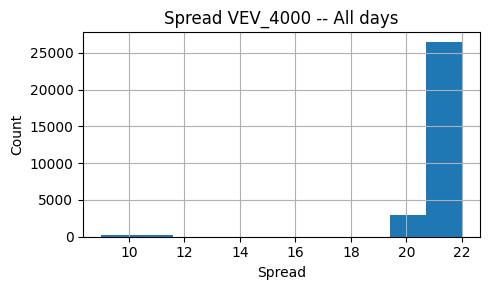

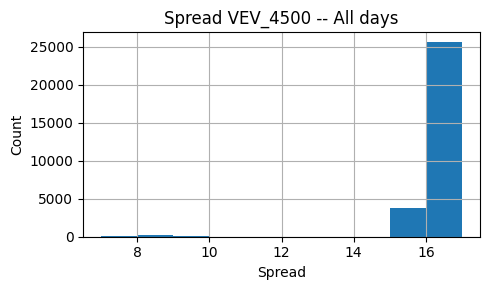

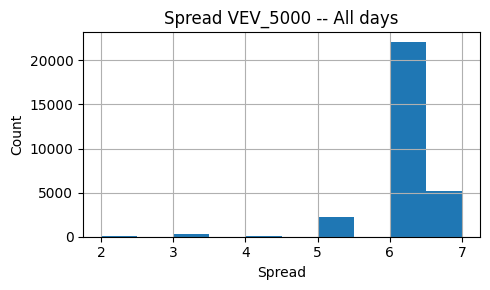

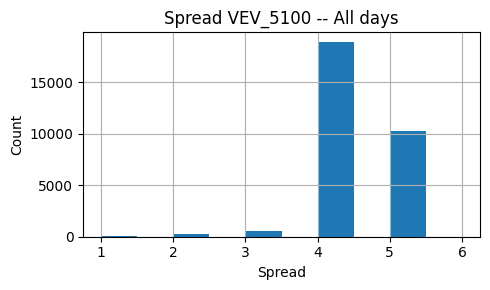

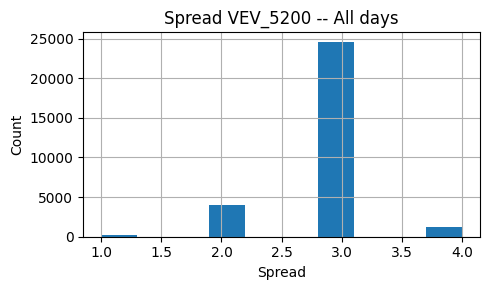

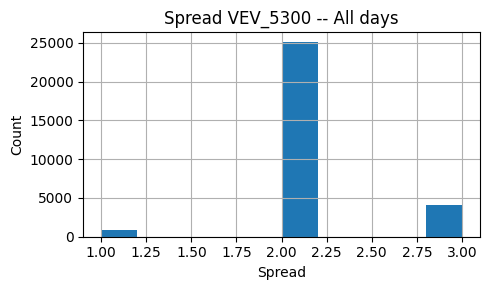

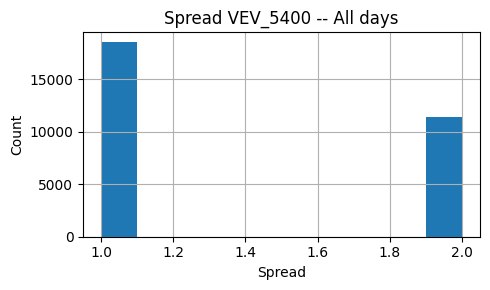

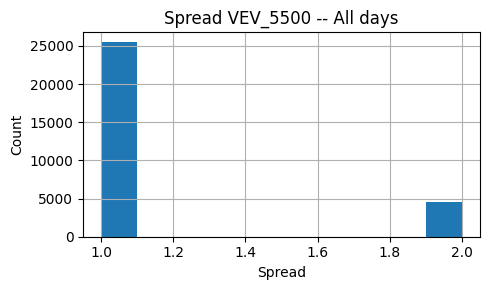

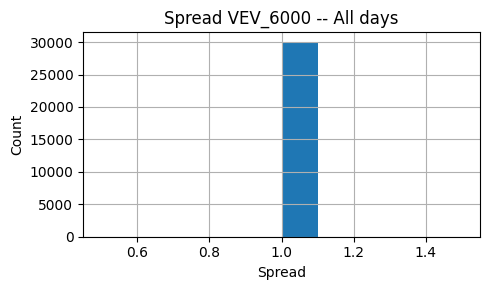

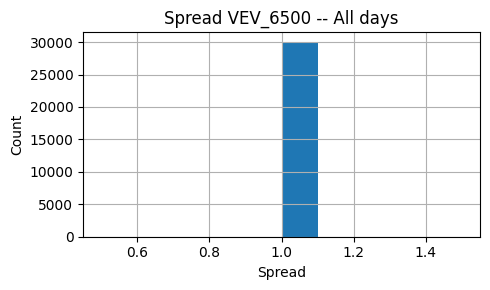

In [11]:
for voucher in vouchers:
    voucher_price_df = voucher_prices[voucher_prices["product"]==voucher]
    ax = voucher_price_df["spread"].hist(figsize = (5,3))
    ax.set_title(f"Spread {voucher} -- All days")
    ax.set_xlabel(f"Spread")
    ax.set_ylabel(f"Count")
    plt.tight_layout()
    plt.show()

The voucher products show very different spread and price regimes across strikes. `VEV_4000` and `VEV_4500` have much wider spreads and high prices because they are deep ITM, while higher-strike vouchers such as `VEV_5400`, `VEV_5500`, `VEV_6000`, and `VEV_6500` have much tighter spreads and lower prices.

A wider spread can be attractive because there is more room to earn spread-capture PnL. However, it also makes the observed mid-price a noisier input for implied-volatility calculations. This matters when inferring implied volatility and fitting a live smile.

We focus on `VEV_5000` to `VEV_5300`. These middle strikes have moderate spreads, enough price variation, and option values that were less dominated by intrinsic value than the deep ITM vouchers. Deep ITM vouchers can still be traded, but require more careful treatment because their fair values are highly sensitive to the estimated fair value of `VELVETFRUIT_EXTRACT`.

### Implied volatility analysis

In [12]:
vouchers_for_IV = [
    'VEV_5000',
    'VEV_5100',
    'VEV_5200',
    'VEV_5300'
]

options_df = voucher_prices[
    voucher_prices["product"].isin(vouchers_for_IV)
].copy()

options_df["strike"] = (options_df["product"].str.split("_").str[1].astype(int))


In [13]:
vfe_prices = prices_r3[prices_r3["product"] == "VELVETFRUIT_EXTRACT"][["day", "timestamp", "mid_price"]].copy()

vfe_prices = vfe_prices.rename(columns={"mid_price": "vfe_mid"})

In [14]:
options_df = options_df.merge(vfe_prices,on=["day", "timestamp"],how="left")
options_df[["day", "timestamp", "product", "mid_price", "strike", "vfe_mid"]].head()

,day,timestamp,product,mid_price,strike,vfe_mid
0,0,0,VEV_5200,101.5,5200,5250.0
1,0,0,VEV_5300,53.0,5300,5250.0
2,0,0,VEV_5000,257.0,5000,5250.0
3,0,0,VEV_5100,171.5,5100,5250.0
4,0,100,VEV_5000,258.0,5000,5250.5


In [15]:
day_to_tte = {
    0: 8 / 365,
    1: 7 / 365,
    2: 6 / 365,
}

options_df["tte"] = options_df["day"].map(day_to_tte)

In [16]:
def bs_call_price(S, K, T, sigma, r = 0.0): # compute option price
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

def implied_volatility_call(price, S, K, T, r=0.0):
    intrinsic = max(S - K, 0)

    if price < intrinsic:
        return np.nan
    
    def error(sigma):
        return bs_call_price(S, K, T, sigma, r) - price

    try:
        return brentq(error, 0.01, 1.0)
    
    except ValueError:
        return np.nan



In [17]:
ivs = []
for idx, row in options_df.iterrows():
    iv = implied_volatility_call(price = row["mid_price"], S = row["vfe_mid"],
                                 K = row["strike"], T = row["tte"], r = 0.0)
    ivs.append(iv)

options_df["implied_volatility"] = ivs

In [18]:
options_df["implied_volatility"].isna().sum()

np.int64(3)

In [19]:
options_df.groupby("product")["implied_volatility"].agg(["mean","std","median","min","max"])

,mean,std,median,min,max
product,,,,,
VEV_5000,0.232836,0.010244,0.232902,0.010000,0.276095
VEV_5100,0.230764,0.007564,0.232246,0.201245,0.253182
VEV_5200,0.233332,0.006217,0.233350,0.216350,0.251663
VEV_5300,0.235847,0.005546,0.235269,0.219795,0.255129


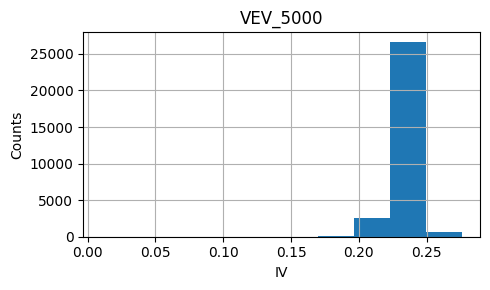

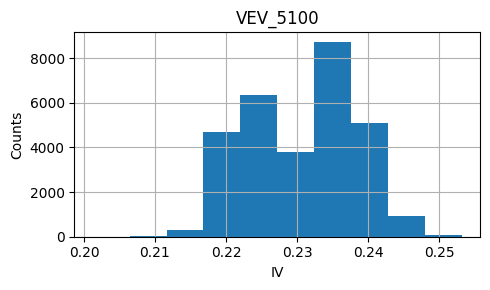

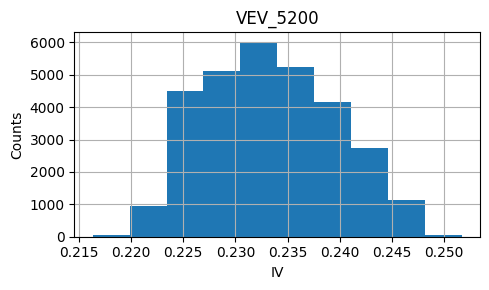

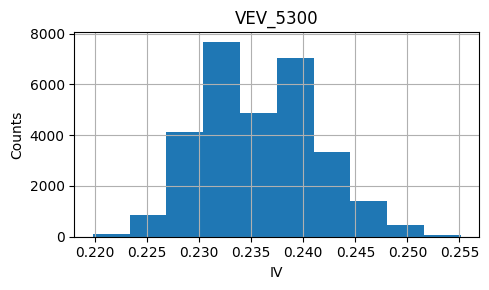

In [20]:

for product, df in options_df.groupby("product"):
    ax = df["implied_volatility"].hist(figsize = (5,3))
    ax.set_title(f"{product}")
    ax.set_xlabel(f"IV")
    ax.set_ylabel(f"Counts")
    plt.tight_layout()
    plt.show()

The selected vouchers have implied volatilities mostly clustered around 23%–24%, which means the middle strikes are priced under a broadly similar volatility level. This makes IV a useful way to compare prices across strikes.

The average IV is not perfectly flat: `VEV_5100` is slightly lower, while `VEV_5300` is slightly higher. This suggests a mild strike-dependent IV pattern. Very low IV values, especially for `VEV_5000`, should be treated carefully because they can occur when the option price is close to intrinsic value.

### Volatility Smile Across Strikes

In [21]:
iv_smile = (
    options_df.groupby(["day", "strike"])["implied_volatility"].median().reset_index()
)

iv_smile

,day,strike,implied_volatility
0,0,5000,0.233803
1,0,5100,0.236624
2,0,5200,0.232747
3,0,5300,0.232137
4,1,5000,0.230926
5,1,5100,0.226943
6,1,5200,0.236252
7,1,5300,0.238755
8,2,5000,0.233482
9,2,5100,0.223938


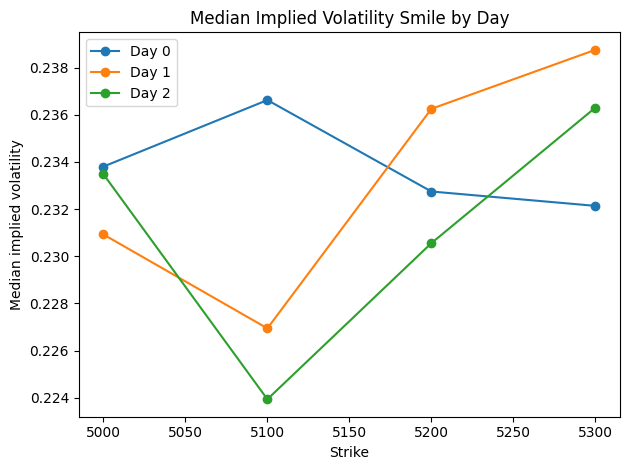

In [22]:
for day, day_df in iv_smile.groupby("day"):
    plt.plot(day_df["strike"], day_df["implied_volatility"], marker="o", label=f"Day {day}")

plt.xlabel("Strike")
plt.ylabel("Median implied volatility")
plt.title("Median Implied Volatility Smile by Day")
plt.legend()
plt.tight_layout()
plt.show()

The median implied-volatility smile is broadly stable across the selected strikes, with IVs mostly between 22.5% and 24%. This suggests that `VEV_5000` to `VEV_5300` share a similar volatility regime.

The curve is not completely flat: Days 1 and 2 show lower median IV around `VEV_5100` and higher IV toward `VEV_5300`, indicating a mild strike-dependent pattern. However, the differences are relatively small.

### Relationship Between Vouchers and the Underlying

In [23]:
products_for_corr = [
    "VELVETFRUIT_EXTRACT",
    "VEV_5000",
    "VEV_5100",
    "VEV_5200",
    "VEV_5300",
]

corr_df = prices_r3[
    prices_r3["product"].isin(products_for_corr)
].copy()

wide_prices = corr_df.pivot_table(
    index=["day", "timestamp"],
    columns="product",
    values="mid_price"
)

In [24]:
wide_prices.corr()["VELVETFRUIT_EXTRACT"].loc[
    ["VEV_5000", "VEV_5100", "VEV_5200", "VEV_5300"]
]

product
VEV_5000    0.995217
VEV_5100    0.962068
VEV_5200    0.913988
VEV_5300    0.837224
Name: VELVETFRUIT_EXTRACT, dtype: float64

The selected vouchers are positively correlated with `VELVETFRUIT_EXTRACT`, confirming that VFE is the relevant underlying for the voucher-pricing analysis.

The voucher correlations decrease as strike increases. This is consistent with call-option behaviour: lower-strike vouchers such as `VEV_5000` are more in-the-money and therefore behave more like the underlying, while higher-strike vouchers such as `VEV_5300` are more option-like and less mechanically tied to current VFE moves.